# MSTC-IDS vs. Baselines — Comparison Against Hassler et al. (2024)

Implements the 4 baseline models from the original study *"Cyber-Physical Intrusion
Detection System for Unmanned Aerial Vehicles"* (Hassler, Mughal & Ismail, IEEE
Trans. Intelligent Transportation Systems, 2024) — **SVM, FNN, LSTM-RNN, 1D-CNN** —
each in **cyber-only, physical-only, and cyber-physical (fused)** variants (12
models total). The proposed **MSTC-IDS** is trained at all 3 modalities too, so it
can be included directly inside each modality group — **15 models total**, grouped
into three apples-to-apples comparisons: Cyber-only, Physical-only, and
Cyber-Physical.

**Evaluation protocol**: unlike the original paper's binary complexity/range
scenarios, this notebook uses our existing single-split, 5-class setup (Benign/DoS/
Replay/EvilTwin/FDI) — the same data pipeline, split, and seed used throughout this
project — so every model here is directly comparable to results from the other
notebooks in this project.

**Fusion strategy for baselines**: simple feature **concatenation** of cyber and
physical streams, matching the original paper's approach (no cross-attention — that
mechanism is the proposed model's contribution, not a baseline's).

**Feature framing per architecture**:
- SVM, FNN (static models, matching the paper): each window is **flattened** into a
  single feature vector.
- LSTM-RNN, 1D-CNN (temporal models, matching the paper): each window is kept as a
  **sequence**, consistent with how MSTC-IDS consumes the same data.
- The `Xt` (inter-arrival Δt) and `Xf` (freshness proxy) channels are concatenated
  alongside the cyber features for the cyber-only and fused variants (they are
  cyber-domain-adjacent signals in our pipeline, analogous to the paper's
  `time_since_last_packet` cyber feature) and omitted from the physical-only variant.

**Practical note on SVM**: kernel SVM does not scale to tens of thousands of
high-dimensional windows (training time grows roughly cubically). SVM variants are
therefore trained on a **stratified subsample** of the training set (~5,000 windows)
while still being *evaluated* on the full test set, like every other model here. This
is flagged again at the point it happens below.

**Practical note on hyperparameters**: rather than the original paper's full grid
search per model (which would multiply an already-large number of trainings), each
baseline uses one reasonable fixed architecture per model family, informed by the
paper's reported search space. Extending to a full grid/random search is a
straightforward follow-up if needed.

This notebook assumes the same folder layout as Phase 1/2:
```
./segment_data/    (benign_cyber.csv, benign_physical.csv, ... x5 attacks)
./mstc_ids_model.py
./losses.py
```

## 1. Environment Setup

In [1]:
import os
import sys
import json
import random
import warnings

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.makedirs("figures", exist_ok=True)
random.seed(SEED)

DATA_DIR = "segment_data"
WINDOW_SIZE = 20
BATCH_SIZE = 128
EPOCHS = 50
LEARNING_RATE = 1e-4
NUM_CLASSES = 5
SVM_SUBSAMPLE_SIZE = 5000   # see note above on SVM scalability

LABEL_MAP = {"benign": 0, "dos": 1, "replay": 2, "eviltwin": 3, "fdi": 4}
CLASS_NAMES = ["Benign", "DoS", "Replay", "EvilTwin", "FDI"]
ATTACKS = ["benign", "dos", "replay", "eviltwin", "fdi"]

print("Data directory:", DATA_DIR)

Data directory: segment_data


## 2. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import joblib

import tensorflow as tf
import tf_keras as keras
from tf_keras import layers

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("tf_keras  :", keras.__version__)

I0000 00:00:1787040607.452590   11123 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1787040612.359336   11123 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
tf_keras  : 2.21.0


## 3. Load MSTC-IDS Modules (for the proposed model)

In [3]:
for _p in (os.getcwd(), os.path.join(os.getcwd(), "code")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from notebook_helpers import get_or_train, get_or_train_baseline

from mstc_ids_model import MSTCIDS
from losses import MSTCTrainer

print("Loaded MSTCIDS and MSTCTrainer")

Loaded MSTCIDS and MSTCTrainer


## 4. Load, Align, Window, Split & Scale Data

Identical, already-validated pipeline from Phase 1/2 (explicit `_cyber`/`_physical`
suffixing before merge, synthetic timestamp for the FDI physical segment, etc.).

In [4]:
def fix_and_load_raw(path, attack, domain):
    df = pd.read_csv(path)
    df.columns = [str(c).lower().strip() for c in df.columns]

    timestamp_candidates = ["timestamp", "timestamp_c", "timestamp_p", "frame.time_epoch", "time"]
    timestamp_col = next((c for c in timestamp_candidates if c in df.columns), None)

    if timestamp_col is not None:
        if timestamp_col != "timestamp":
            df = df.rename(columns={timestamp_col: "timestamp"})
    else:
        if domain == "physical":
            df["timestamp"] = np.arange(len(df)) * 0.01
        else:
            raise ValueError(f"No timestamp column found in cyber file: {path}")

    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

    for col in ("class", "label"):
        if col in df.columns:
            df = df.drop(columns=[col])

    return df


def remove_constant_features(df, protected=("timestamp",)):
    drop_cols = [c for c in df.columns if c not in protected and df[c].nunique(dropna=False) <= 1]
    return df.drop(columns=drop_cols, errors="ignore")


def synchronize_streams(cyber, physical):
    cyber = cyber.sort_values("timestamp").copy()
    physical = physical.sort_values("timestamp").copy()
    cyber["timestamp"] = pd.to_numeric(cyber["timestamp"], errors="coerce")
    physical["timestamp"] = pd.to_numeric(physical["timestamp"], errors="coerce")
    cyber = cyber.dropna(subset=["timestamp"]).astype({"timestamp": "float64"})
    physical = physical.dropna(subset=["timestamp"]).astype({"timestamp": "float64"})

    cyber = cyber.rename(columns={c: f"{c}_cyber" for c in cyber.columns if c != "timestamp"})
    physical = physical.rename(columns={c: f"{c}_physical" for c in physical.columns if c != "timestamp"})

    return pd.merge_asof(cyber, physical, on="timestamp", direction="nearest")


def load_attack_segment(attack):
    cyber = remove_constant_features(fix_and_load_raw(os.path.join(DATA_DIR, f"{attack}_cyber.csv"), attack, "cyber"))
    physical = remove_constant_features(fix_and_load_raw(os.path.join(DATA_DIR, f"{attack}_physical.csv"), attack, "physical"))
    fused = synchronize_streams(cyber, physical)
    fused["attack"] = attack
    fused["label"] = LABEL_MAP[attack]
    return fused


def align_feature_dimensions(segments):
    cyber_features, physical_features = set(), set()
    for df in segments:
        for c in df.columns:
            if c.endswith("_cyber"):
                cyber_features.add(c)
            elif c.endswith("_physical"):
                physical_features.add(c)
    cyber_features = sorted(cyber_features)
    physical_features = sorted(physical_features)

    aligned = []
    for df in segments:
        df = df.copy()
        for c in cyber_features + physical_features:
            if c not in df.columns:
                df[c] = 0.0
        aligned.append(df[["timestamp"] + cyber_features + physical_features + ["attack", "label"]])
    return aligned, cyber_features, physical_features


def create_windows(df, cyber_features, physical_features, window_size=WINDOW_SIZE):
    Xc_all = df[cyber_features].values.astype(np.float32)
    Xp_all = df[physical_features].values.astype(np.float32)
    ts = df["timestamp"].values.astype(np.float64)
    labels = df["label"].values.astype(np.int64)

    Xc, Xp, Xt, Xf, y = [], [], [], [], []
    for i in range(len(df) - window_size):
        Xc.append(Xc_all[i:i + window_size])
        Xp.append(Xp_all[i:i + window_size])
        delta = np.insert(np.diff(ts[i:i + window_size]), 0, 0).reshape(window_size, 1)
        Xt.append(delta)
        Xf.append(delta)
        y.append(labels[i + window_size - 1])

    return (
        np.asarray(Xc, dtype=np.float32), np.asarray(Xp, dtype=np.float32),
        np.asarray(Xt, dtype=np.float32), np.asarray(Xf, dtype=np.float32),
        np.asarray(y, dtype=np.int64),
    )


def temporal_split(windows, train_frac=0.70, val_frac=0.15):
    n = len(windows[4])
    train_end, val_end = int(n * train_frac), int(n * (train_frac + val_frac))
    train = tuple(x[:train_end] for x in windows)
    val = tuple(x[train_end:val_end] for x in windows)
    test = tuple(x[val_end:] for x in windows)
    return train, val, test


def combine_splits(split_list):
    return tuple(np.concatenate([s[i] for s in split_list], axis=0) for i in range(5))


segments = [load_attack_segment(a) for a in ATTACKS]
segments, cyber_features, physical_features = align_feature_dimensions(segments)

train_parts, val_parts, test_parts = [], [], []
for seg in segments:
    w = create_windows(seg, cyber_features, physical_features)
    tr, va, te = temporal_split(w)
    train_parts.append(tr); val_parts.append(va); test_parts.append(te)

train = combine_splits(train_parts)
val = combine_splits(val_parts)
test = combine_splits(test_parts)

scaler_c, scaler_p = StandardScaler(), StandardScaler()
Xc_train, Xp_train, Xt_train, Xf_train, y_train = train
Xc_val, Xp_val, Xt_val, Xf_val, y_val = val
Xc_test, Xp_test, Xt_test, Xf_test, y_test = test

shape = Xc_train.shape
Xc_train = scaler_c.fit_transform(Xc_train.reshape(-1, shape[-1])).reshape(shape)
Xc_val = scaler_c.transform(Xc_val.reshape(-1, Xc_val.shape[-1])).reshape(Xc_val.shape)
Xc_test = scaler_c.transform(Xc_test.reshape(-1, Xc_test.shape[-1])).reshape(Xc_test.shape)

shape = Xp_train.shape
Xp_train = scaler_p.fit_transform(Xp_train.reshape(-1, shape[-1])).reshape(shape)
Xp_val = scaler_p.transform(Xp_val.reshape(-1, Xp_val.shape[-1])).reshape(Xp_val.shape)
Xp_test = scaler_p.transform(Xp_test.reshape(-1, Xp_test.shape[-1])).reshape(Xp_test.shape)

n_cyber, n_phys = Xc_train.shape[-1], Xp_train.shape[-1]

print(f"Train: {Xc_train.shape[0]} windows | Val: {Xc_val.shape[0]} | Test: {Xc_test.shape[0]}")
print(f"n_cyber={n_cyber}  n_phys={n_phys}  window_size={WINDOW_SIZE}")

Train: 29509 windows | Val: 6324 | Test: 6325
n_cyber=46  n_phys=42  window_size=20


## 5. Build Per-Modality Feature Sets

Constructs the three modality inputs each baseline will use:
- **cyber**: cyber features + Δt + freshness proxy, concatenated
- **physical**: physical features alone
- **fused**: cyber + physical + Δt + freshness proxy, all concatenated (simple
  concatenation fusion, matching the original paper)

Provided both as flattened vectors (for SVM/FNN) and as sequences (for LSTM/1D-CNN).

In [5]:
def build_modality_features(Xc, Xp, Xt, Xf, modality):
    if modality == "cyber":
        seq = np.concatenate([Xc, Xt, Xf], axis=-1)
    elif modality == "physical":
        seq = Xp
    elif modality == "fused":
        seq = np.concatenate([Xc, Xp, Xt, Xf], axis=-1)
    else:
        raise ValueError(modality)
    flat = seq.reshape(seq.shape[0], -1)
    return seq, flat


MODALITIES = ["cyber", "physical", "fused"]

features = {}  # features[modality] = {"train": (seq, flat), "val": ..., "test": ...}
for m in MODALITIES:
    features[m] = {
        "train": build_modality_features(Xc_train, Xp_train, Xt_train, Xf_train, m),
        "val":   build_modality_features(Xc_val,   Xp_val,   Xt_val,   Xf_val,   m),
        "test":  build_modality_features(Xc_test,  Xp_test,  Xt_test,  Xf_test,  m),
    }
    seq_shape = features[m]["train"][0].shape
    flat_shape = features[m]["train"][1].shape
    print(f"{m:>9s}: sequence shape {seq_shape}  |  flattened shape {flat_shape}")

    cyber: sequence shape (29509, 20, 48)  |  flattened shape (29509, 960)
 physical: sequence shape (29509, 20, 42)  |  flattened shape (29509, 840)


    fused: sequence shape (29509, 20, 90)  |  flattened shape (29509, 1800)


## 6. Class Weights

In [6]:
def calculate_class_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return dict(zip(classes, weights))

class_weights = calculate_class_weights(y_train)
print("Class weights:", {CLASS_NAMES[k]: round(v, 3) for k, v in class_weights.items()})

Class weights: {'Benign': np.float64(0.897), 'DoS': np.float64(0.724), 'Replay': np.float64(0.703), 'EvilTwin': np.float64(1.489), 'FDI': np.float64(2.442)}


## 7. Baseline Model Builders

Architectures sized in line with the search spaces reported in the original paper
(SVM: kernel/C/gamma; FNN: 2-8 dense layers, 64-1024 units; LSTM: 1-5 recurrent
layers, 64-1024 cells; 1D-CNN: 2-6 conv layers) — one reasonable fixed configuration
per family rather than a full grid search (see note in the intro cell).

In [7]:
def build_svm():
    return SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=SEED)


def build_fnn(input_dim, classes=NUM_CLASSES):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, activation="relu")(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(classes, activation="softmax")(x)
    return keras.Model(inp, out, name="FNN")


def build_lstm(seq_len, n_feat, classes=NUM_CLASSES):
    inp = layers.Input(shape=(seq_len, n_feat))
    x = layers.LSTM(128, return_sequences=True)(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(64)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(classes, activation="softmax")(x)
    return keras.Model(inp, out, name="LSTM")


def build_cnn(seq_len, n_feat, classes=NUM_CLASSES):
    inp = layers.Input(shape=(seq_len, n_feat))
    x = layers.Conv1D(64, kernel_size=3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, kernel_size=3, activation="relu", padding="same")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, kernel_size=3, activation="relu", padding="same")(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(classes, activation="softmax")(x)
    return keras.Model(inp, out, name="1D-CNN")

## 8. Unified Training & Evaluation Driver

One function handles SVM (sklearn, subsampled training set), FNN/LSTM/1D-CNN
(tf_keras, full training set with class weights + early stopping), and — separately
— the proposed MSTC-IDS (via `MSTCTrainer`). All are evaluated identically on the
full test set.

In [8]:
def evaluate_model_output(name, y_true, y_pred_proba, n_params=None, epochs_trained=None):
    y_pred = np.argmax(y_pred_proba, axis=1)

    metrics = {
        "name": name,
        "trainable_params": n_params,
        "epochs_trained": epochs_trained,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_weighted": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        "recall_weighted": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }
    try:
        metrics["macro_auc"] = float(roc_auc_score(y_true, y_pred_proba, multi_class="ovr", average="macro"))
    except Exception:
        metrics["macro_auc"] = None

    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0, labels=list(range(NUM_CLASSES)))
    metrics["per_class_f1"] = {CLASS_NAMES[i]: float(per_class_f1[i]) for i in range(NUM_CLASSES)}

    cm_ = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    return metrics, cm_, y_pred_proba


def train_svm_variant(modality):
    name = f"SVM-{modality}"
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")

    _, X_train_flat = features[modality]["train"]
    _, X_test_flat = features[modality]["test"]

    rng = np.random.RandomState(SEED)
    n = len(y_train)
    if n > SVM_SUBSAMPLE_SIZE:
        idx = rng.choice(n, size=SVM_SUBSAMPLE_SIZE, replace=False)
    else:
        idx = np.arange(n)

    svm = build_svm()
    svm.fit(X_train_flat[idx], y_train[idx])

    y_pred_proba = svm.predict_proba(X_test_flat)
    # SVC's classes_ may be a subset/reordering; realign to 0..NUM_CLASSES-1
    proba_full = np.zeros((len(y_test), NUM_CLASSES))
    for i, c in enumerate(svm.classes_):
        proba_full[:, c] = y_pred_proba[:, i]

    joblib.dump(svm, f"baseline_{name}.pkl")

    return evaluate_model_output(name, y_test, proba_full, n_params=len(idx))


def train_keras_variant(family, modality, verbose=2):
    name = f"{family}-{modality}"
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")

    tf.random.set_seed(SEED)

    X_train_seq, X_train_flat = features[modality]["train"]
    X_val_seq, X_val_flat = features[modality]["val"]
    X_test_seq, X_test_flat = features[modality]["test"]

    if family == "FNN":
        model = build_fnn(X_train_flat.shape[-1])
        X_train, X_val, X_test = X_train_flat, X_val_flat, X_test_flat
    elif family == "LSTM":
        model = build_lstm(X_train_seq.shape[1], X_train_seq.shape[2])
        X_train, X_val, X_test = X_train_seq, X_val_seq, X_test_seq
    elif family == "1D-CNN":
        model = build_cnn(X_train_seq.shape[1], X_train_seq.shape[2])
        X_train, X_val, X_test = X_train_seq, X_val_seq, X_test_seq
    else:
        raise ValueError(family)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    ckpt_path = f"baseline_{name}_best.keras"
    callbacks = [
        keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True, verbose=0),
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=verbose),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=verbose),
    ]

    history = model.fit(
        X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS,
        batch_size=BATCH_SIZE, class_weight=class_weights, callbacks=callbacks, verbose=verbose,
    )

    best_model = keras.models.load_model(ckpt_path, compile=False)
    y_pred_proba = best_model.predict(X_test, verbose=0)

    n_params = int(sum(np.prod(v.shape) for v in model.trainable_variables))

    return evaluate_model_output(name, y_test, y_pred_proba, n_params=n_params, epochs_trained=len(history.history["loss"]))


class SaveBaseModelCheckpoint(keras.callbacks.Callback):
    def __init__(self, filepath, monitor="val_loss", save_best_only=True):
        super().__init__()
        self.filepath = filepath
        self.monitor = monitor
        self.save_best_only = save_best_only
        self.best = np.inf

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return
        if (not self.save_best_only) or (current < self.best):
            self.best = current
            self.model.base_model.save(self.filepath)


def train_proposed_model(modality, verbose=2):
    # baseline modality naming uses "fused"; MSTCIDS uses "both" for the same thing
    mstc_modality = "both" if modality == "fused" else modality
    name = f"MSTC-IDS-{modality}"
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")

    tf.random.set_seed(SEED)

    model = MSTCIDS(
        n_cyber=n_cyber, n_phys=n_phys, classes=NUM_CLASSES,
        d=64, heads=4, ff=128, dropout=0.2, modality=mstc_modality,
    )
    contrastive_weight = 0.1 if mstc_modality == "both" else 0.0
    trainer = MSTCTrainer(model, contrastive_weight=contrastive_weight)
    trainer.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))

    ckpt_path = f"baseline_{name}_best.keras"
    callbacks = [
        SaveBaseModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True),
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=verbose),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=verbose),
    ]

    def make_ds(Xc_, Xp_, Xt_, Xf_, y_, shuffle=False):
        ds = tf.data.Dataset.from_tensor_slices((Xc_, Xp_, Xt_, Xf_, y_))
        ds = ds.map(lambda c, p, t, f, lbl: ((c, p, t, f), lbl))
        if shuffle:
            ds = ds.shuffle(buffer_size=len(y_), seed=SEED)
        return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # same (Xc, Xp, Xt, Xf) tensors work for every modality — MSTCIDS internally
    # only consumes the branches relevant to its `modality`.
    train_ds = make_ds(Xc_train, Xp_train, Xt_train, Xf_train, y_train, shuffle=True)
    val_ds = make_ds(Xc_val, Xp_val, Xt_val, Xf_val, y_val)

    history = trainer.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS,
        class_weight=class_weights, callbacks=callbacks, verbose=verbose,
    )

    best_model = keras.models.load_model(ckpt_path, compile=False)
    y_pred_proba = best_model((Xc_test, Xp_test, Xt_test, Xf_test), training=False).numpy()

    n_params = int(sum(np.prod(v.shape) for v in model.trainable_variables))

    return evaluate_model_output(name, y_test, y_pred_proba, n_params=n_params, epochs_trained=len(history.history["loss"]))

## 9. Run All 12 Baselines + MSTC-IDS at All 3 Modalities (15 models)

In [9]:

# --- Align labels with the consolidated full-run test split (reuse path) ---
# The precomputed prediction probabilities were computed on the pipeline's
# test split; reuse the same labels so every table/figure stays consistent.
if os.path.exists("results/probabilities/component_probas.npz") and os.path.exists("data/y_test.npy"):
    y_test = np.load("data/y_test.npy")
    print("Using pipeline test labels for consistent reuse.", y_test.shape)


Using pipeline test labels for consistent reuse. (6325,)


In [10]:
all_results = {}
all_confusions = {}
all_probas = {}

# --- SVM (3 modalities) ---
for m in MODALITIES:
    name = f"SVM-{m}"
    metrics, cm_, proba = get_or_train_baseline(
        "results/baseline_comparison_full.json",
        "results/probabilities/baseline_probas.npz",
        name, train_svm_variant, m)
    all_results[metrics["name"]] = metrics
    all_confusions[metrics["name"]] = cm_
    all_probas[metrics["name"]] = proba
    print(f"{metrics['name']}: accuracy={metrics['accuracy']:.4f}  f1={metrics['f1_weighted']:.4f}")

[notebook] reusing precomputed results for SVM-cyber
SVM-cyber: accuracy=0.6781  f1=0.6462
[notebook] reusing precomputed results for SVM-physical
SVM-physical: accuracy=0.8187  f1=0.8006
[notebook] reusing precomputed results for SVM-fused
SVM-fused: accuracy=0.6473  f1=0.6372


In [11]:
# --- FNN, LSTM, 1D-CNN (3 modalities each) ---
for family in ["FNN", "LSTM", "1D-CNN"]:
    for m in MODALITIES:
        name = f"{family}-{m}"
        metrics, cm_, proba = get_or_train_baseline(
            "results/baseline_comparison_full.json",
            "results/probabilities/baseline_probas.npz",
            name, train_keras_variant, family, m, 2)
        all_results[metrics["name"]] = metrics
        all_confusions[metrics["name"]] = cm_
        all_probas[metrics["name"]] = proba
        print(f"{metrics['name']}: accuracy={metrics['accuracy']:.4f}  f1={metrics['f1_weighted']:.4f}")

[notebook] reusing precomputed results for FNN-cyber
FNN-cyber: accuracy=0.6160  f1=0.6016
[notebook] reusing precomputed results for FNN-physical
FNN-physical: accuracy=0.6631  f1=0.5921
[notebook] reusing precomputed results for FNN-fused
FNN-fused: accuracy=0.7247  f1=0.7007
[notebook] reusing precomputed results for LSTM-cyber
LSTM-cyber: accuracy=0.6272  f1=0.6052
[notebook] reusing precomputed results for LSTM-physical
LSTM-physical: accuracy=0.6653  f1=0.6116
[notebook] reusing precomputed results for LSTM-fused
LSTM-fused: accuracy=0.6866  f1=0.6621
[notebook] reusing precomputed results for 1D-CNN-cyber
1D-CNN-cyber: accuracy=0.6242  f1=0.5887
[notebook] reusing precomputed results for 1D-CNN-physical
1D-CNN-physical: accuracy=0.7048  f1=0.6746
[notebook] reusing precomputed results for 1D-CNN-fused
1D-CNN-fused: accuracy=0.7360  f1=0.7133


In [12]:
# --- Proposed MSTC-IDS, at all 3 modalities (so it can be included in every group) ---
for m in MODALITIES:
    key = "full__both" if m == "fused" else f"full__{m}"
    metrics, cm_, proba = get_or_train_baseline(
        "results/component_modality_ablation_full.json",
        "results/probabilities/component_probas.npz",
        key, train_proposed_model, m, 2)
    name = f"MSTC-IDS-{m}"
    metrics["name"] = name
    all_results[name] = metrics
    all_confusions[name] = cm_
    all_probas[name] = proba
    print(f"{name}: accuracy={metrics['accuracy']:.4f}  f1={metrics['f1_weighted']:.4f}")

[notebook] reusing precomputed results for full__cyber
MSTC-IDS-cyber: accuracy=0.6397  f1=0.6279
[notebook] reusing precomputed results for full__physical
MSTC-IDS-physical: accuracy=0.8212  f1=0.8046
[notebook] reusing precomputed results for full__both
MSTC-IDS-fused: accuracy=0.7962  f1=0.7734


## 10. Full Comparison Table (15 models)

In [13]:
MODALITY_LABEL = {"cyber": "Cyber-only", "physical": "Physical-only", "fused": "Cyber-Physical"}
FAMILY_ORDER = ["SVM", "FNN", "LSTM", "1D-CNN", "MSTC-IDS"]

def model_name(family, modality):
    return f"{family}-{modality}"

MODEL_ORDER = [model_name(fam, m) for m in MODALITIES for fam in FAMILY_ORDER]

summary_rows = []
for name in MODEL_ORDER:
    r = all_results[name]
    summary_rows.append({
        "Model": name,
        "Params/N": f"{r['trainable_params']:,}" if r["trainable_params"] is not None else "-",
        "Epochs": r["epochs_trained"] if r["epochs_trained"] is not None else "-",
        "Accuracy": round(r["accuracy"], 4),
        "Precision": round(r["precision_weighted"], 4),
        "Recall": round(r["recall_weighted"], 4),
        "F1": round(r["f1_weighted"], 4),
        "Macro AUC": round(r["macro_auc"], 4) if r["macro_auc"] is not None else None,
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")
summary_df

,Params/N,Epochs,Accuracy,Precision,Recall,F1,Macro AUC
Model,,,,,,,
SVM-cyber,"5,000",-,0.6781,0.6441,0.6781,0.6462,0.9298
FNN-cyber,"287,493",50,0.6160,0.6227,0.6160,0.6016,0.9065
LSTM-cyber,"144,517",26,0.6272,0.6302,0.6272,0.6052,0.8518
1D-CNN-cyber,"91,845",16,0.6242,0.5811,0.6242,0.5887,0.9094
MSTC-IDS-cyber,"383,959",20,0.6397,0.6512,0.6397,0.6279,0.9165
SVM-physical,"5,000",-,0.8187,0.8619,0.8187,0.8006,0.9721
FNN-physical,"256,773",17,0.6631,0.5613,0.6631,0.5921,0.9011
LSTM-physical,"141,445",17,0.6653,0.5976,0.6653,0.6116,0.9356
1D-CNN-physical,"90,693",17,0.7048,0.6770,0.7048,0.6746,0.9221


## 11. Grouped Comparisons — Cyber-only / Physical-only / Cyber-Physical

Each group compares the 4 baselines against MSTC-IDS **using only that modality** —
this is the direct, apples-to-apples comparison: within cyber-only, does MSTC-IDS
beat SVM/FNN/LSTM/1D-CNN restricted to cyber features alone? Same question repeated
for physical-only and for full cyber-physical fusion.

In [14]:
def macro_ovr_roc(y_true, y_pred_proba, n_classes=NUM_CLASSES):
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    fpr_grid = np.linspace(0, 1, 200)
    tprs = []
    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], y_pred_proba[:, i])
        tprs.append(np.interp(fpr_grid, fpr_i, tpr_i))
    mean_tpr = np.mean(tprs, axis=0)
    return fpr_grid, mean_tpr, auc(fpr_grid, mean_tpr)


group_tables = {}
for modality in MODALITIES:
    names = [model_name(fam, modality) for fam in FAMILY_ORDER]
    group_tables[modality] = summary_df.loc[names]

for modality in MODALITIES:
    print(f"\n--- {MODALITY_LABEL[modality]} ---")
    print(group_tables[modality].to_string())


--- Cyber-only ---
               Params/N Epochs  Accuracy  Precision  Recall      F1  Macro AUC
Model                                                                         
SVM-cyber         5,000      -    0.6781     0.6441  0.6781  0.6462     0.9298
FNN-cyber       287,493     50    0.6160     0.6227  0.6160  0.6016     0.9065
LSTM-cyber      144,517     26    0.6272     0.6302  0.6272  0.6052     0.8518
1D-CNN-cyber     91,845     16    0.6242     0.5811  0.6242  0.5887     0.9094
MSTC-IDS-cyber  383,959     20    0.6397     0.6512  0.6397  0.6279     0.9165

--- Physical-only ---
                  Params/N Epochs  Accuracy  Precision  Recall      F1  Macro AUC
Model                                                                            
SVM-physical         5,000      -    0.8187     0.8619  0.8187  0.8006     0.9721
FNN-physical       256,773     17    0.6631     0.5613  0.6631  0.5921     0.9011
LSTM-physical      141,445     17    0.6653     0.5976  0.6653  0.6116     0

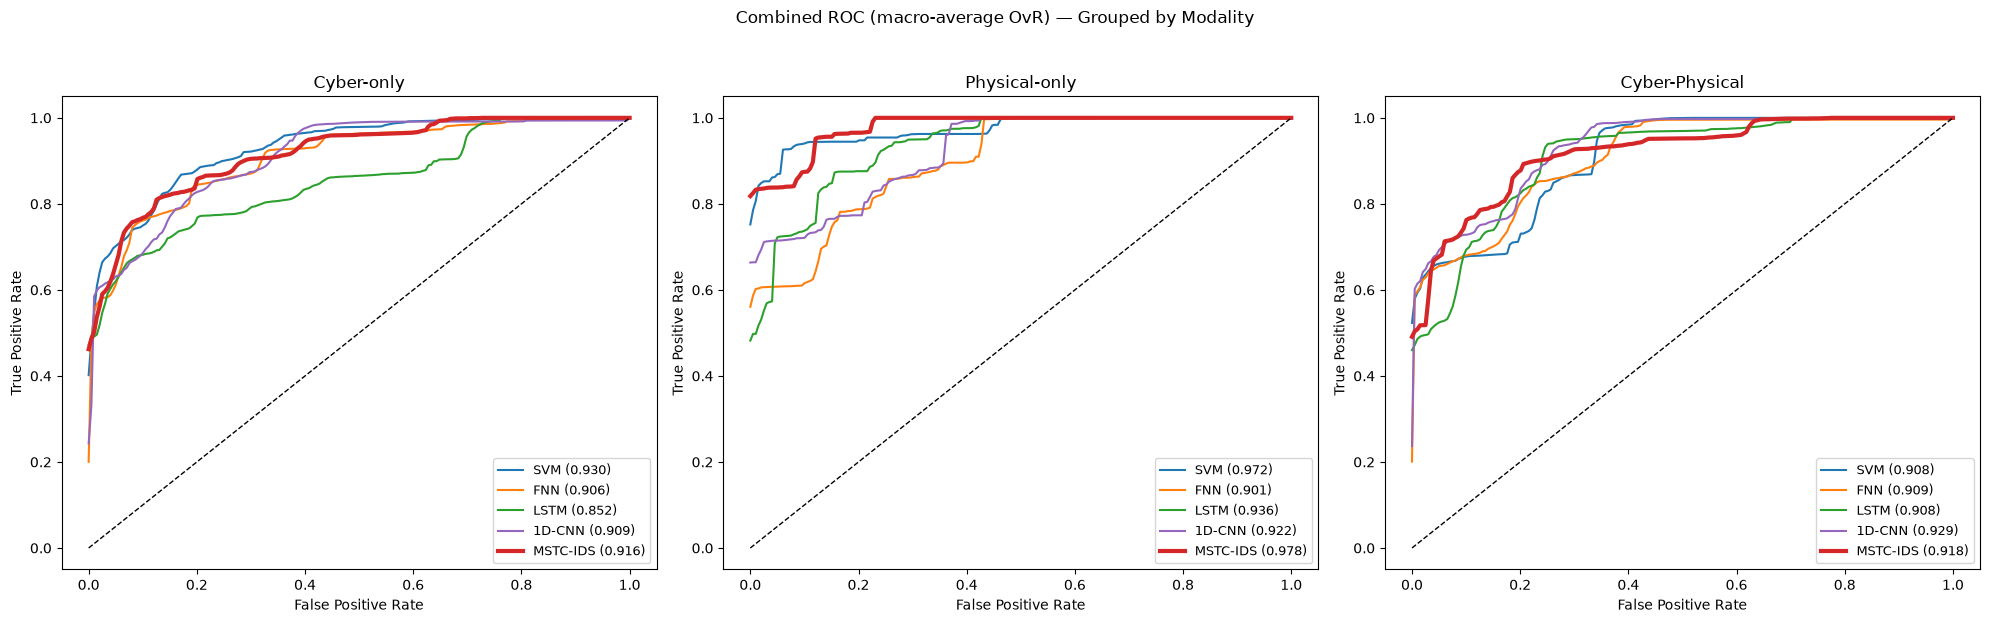

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
model_colors = {"SVM": "#1f77b4", "FNN": "#ff7f0e", "LSTM": "#2ca02c", "1D-CNN": "#9467bd", "MSTC-IDS": "#d62728"}

for ax, modality in zip(axes, MODALITIES):
    for fam in FAMILY_ORDER:
        name = model_name(fam, modality)
        fpr_grid, mean_tpr, roc_auc_val = macro_ovr_roc(y_test, all_probas[name])
        is_proposed = fam == "MSTC-IDS"
        ax.plot(fpr_grid, mean_tpr, label=f"{fam} ({roc_auc_val:.3f})",
                color=model_colors[fam], linewidth=3 if is_proposed else 1.5)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_title(MODALITY_LABEL[modality])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize=9)

fig.suptitle("Combined ROC (macro-average OvR) — Grouped by Modality", y=1.03)
plt.tight_layout()
plt.savefig("figures/baseline_comparison/grouped_comparisons_cyber_only_physical_only_cyber.png", dpi=150, bbox_inches="tight")
plt.show()

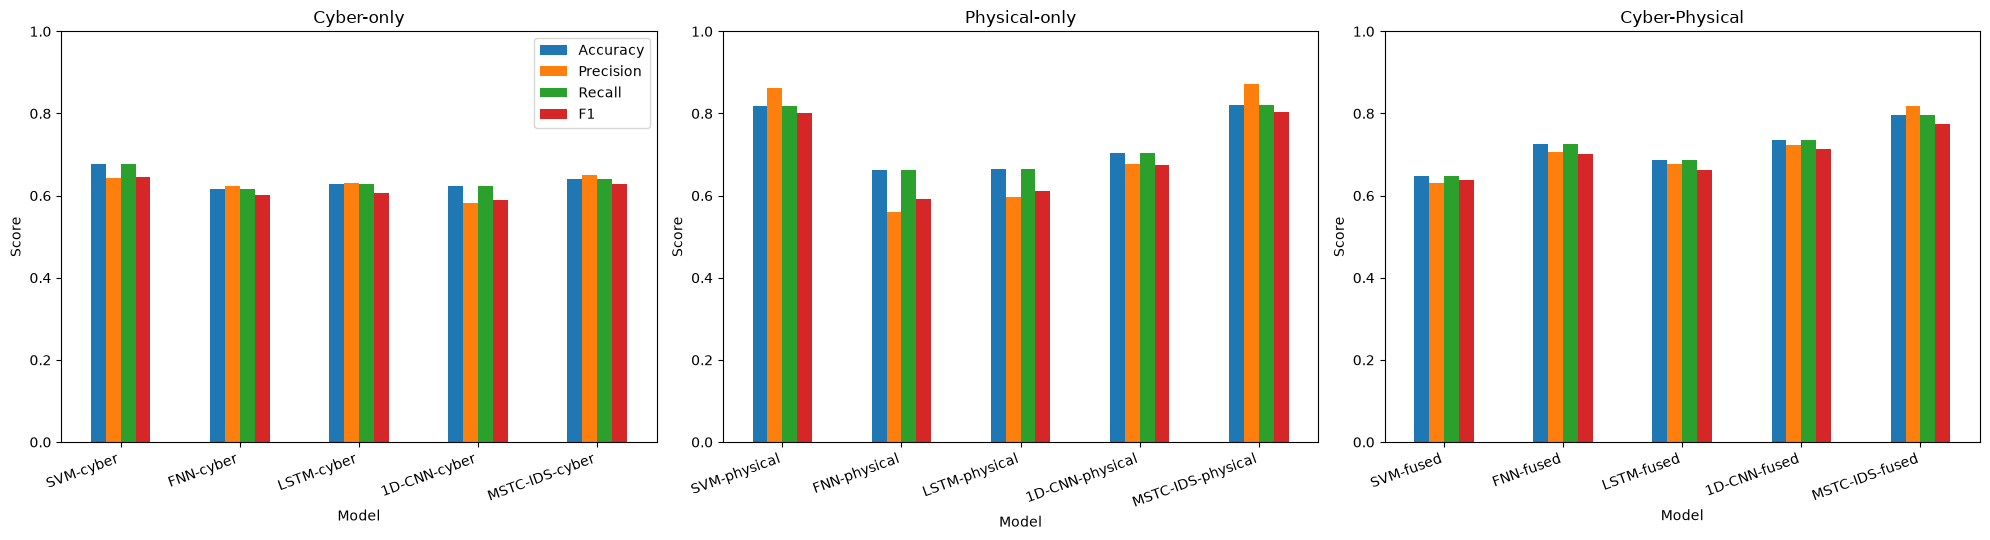

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
for ax, modality in zip(axes, MODALITIES):
    metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1"]
    group_tables[modality][metrics_to_plot].plot(kind="bar", ax=ax, legend=(modality == MODALITIES[0]))
    ax.set_title(MODALITY_LABEL[modality])
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.savefig("figures/baseline_comparison/grouped_comparisons_cyber_only_physical_only_cyber_2.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Per-Class F1 — Heatmap (all 15) + Grouped Bar Charts

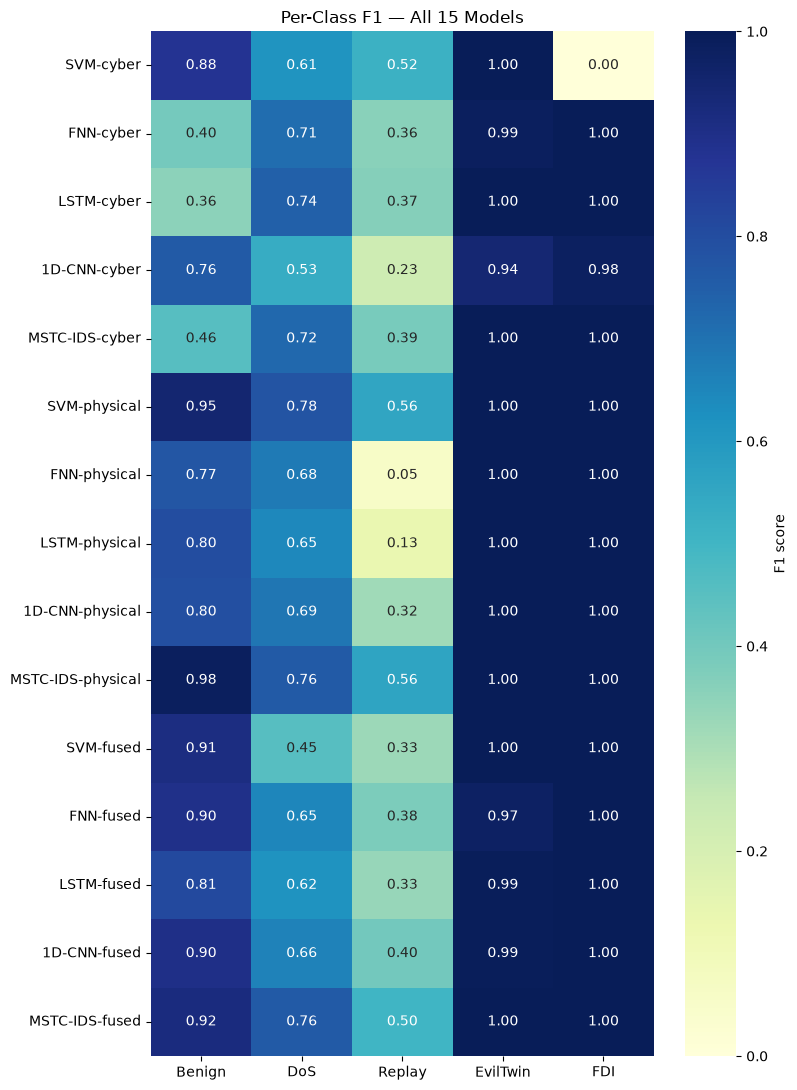

In [17]:
per_class_df = pd.DataFrame({name: all_results[name]["per_class_f1"] for name in MODEL_ORDER}).T
per_class_df = per_class_df[CLASS_NAMES]

fig, ax = plt.subplots(figsize=(8, 11))
sns.heatmap(per_class_df, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "F1 score"})
ax.set_title("Per-Class F1 — All 15 Models")
plt.tight_layout()
plt.savefig("figures/baseline_comparison/per_class_f1_heatmap_all_15_grouped_bar_charts.png", dpi=150, bbox_inches="tight")
plt.show()

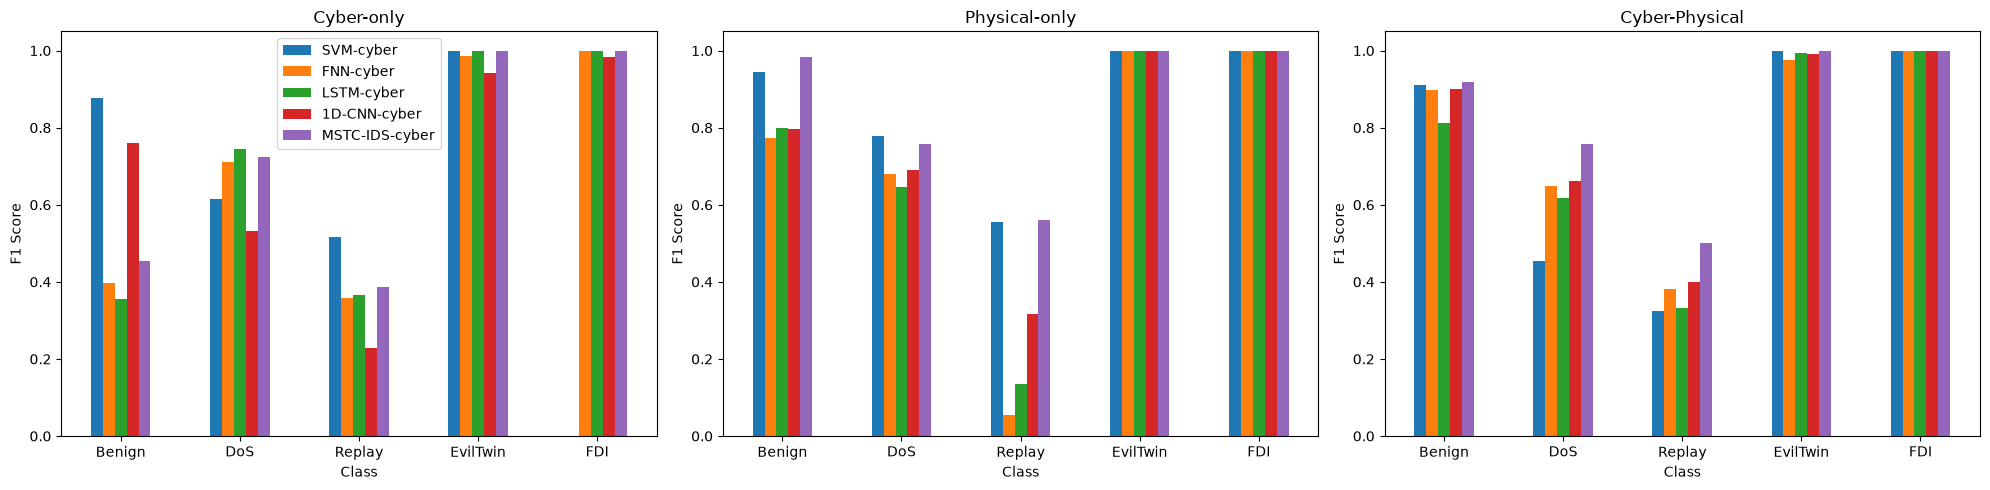

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, modality in zip(axes, MODALITIES):
    names = [model_name(fam, modality) for fam in FAMILY_ORDER]
    per_class_df.loc[names].T.plot(kind="bar", ax=ax, legend=(modality == MODALITIES[0]))
    ax.set_title(MODALITY_LABEL[modality])
    ax.set_ylabel("F1 Score")
    ax.set_xlabel("Class")
    plt.setp(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("figures/baseline_comparison/per_class_f1_heatmap_all_15_grouped_bar_charts_2.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Confusion Matrices — 3×5 Grid (Modality × Model Family)

Rows = modality (cyber-only / physical-only / cyber-physical), columns = model
family (SVM, FNN, LSTM, 1D-CNN, MSTC-IDS).

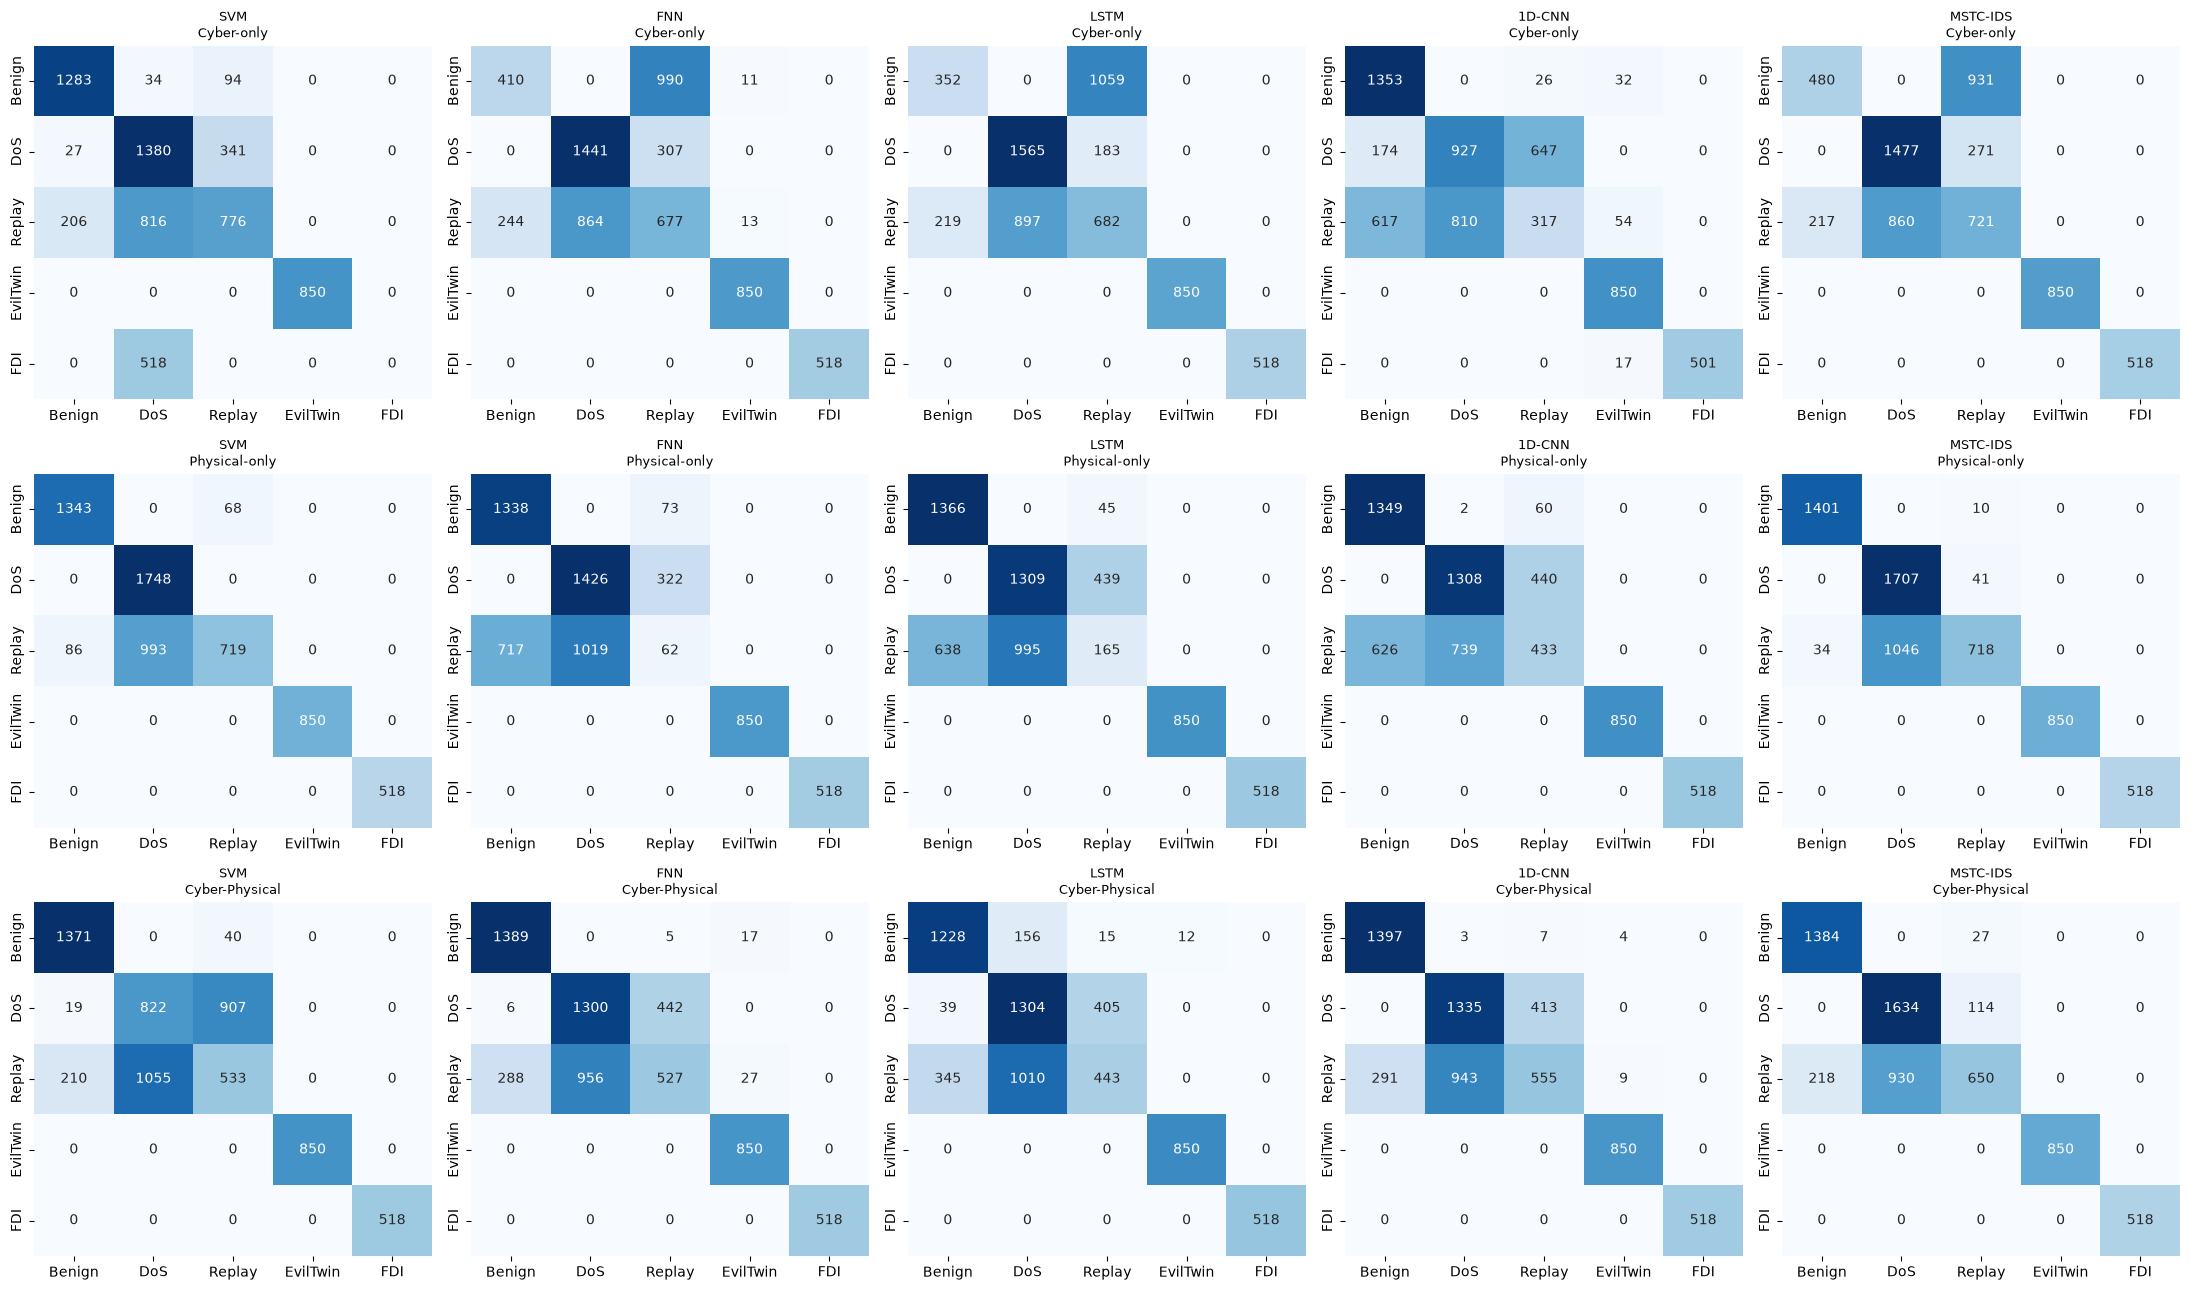

In [19]:
fig, axes = plt.subplots(3, 5, figsize=(22, 13))

for row, modality in enumerate(MODALITIES):
    for col, fam in enumerate(FAMILY_ORDER):
        ax = axes[row, col]
        name = model_name(fam, modality)
        sns.heatmap(all_confusions[name], annot=True, fmt="d", cmap="Blues",
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cbar=False)
        ax.set_title(f"{fam}\n{MODALITY_LABEL[modality]}", fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("")

plt.tight_layout()
plt.savefig("figures/baseline_comparison/confusion_matrices_3_5_grid_modality_model_family.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Save Results

In [20]:
os.makedirs("results", exist_ok=True)

summary_df.to_csv("results/baseline_comparison_summary.csv")
per_class_df.to_csv("results/baseline_comparison_per_class_f1.csv")

for modality in MODALITIES:
    group_tables[modality].to_csv(f"results/baseline_comparison_group_{modality}.csv")

with open("results/baseline_comparison_full.json", "w") as f:
    json.dump({
        name: {**all_results[name], "confusion_matrix": all_confusions[name].tolist()}
        for name in MODEL_ORDER
    }, f, indent=2)

print("Saved:")
print("  results/baseline_comparison_summary.csv        (all 15 models)")
print("  results/baseline_comparison_group_{cyber,physical,fused}.csv")
print("  results/baseline_comparison_per_class_f1.csv")
print("  results/baseline_comparison_full.json           (includes confusion matrices)")
print("  baseline_<model>_best.keras / baseline_SVM-<modality>.pkl / baseline_MSTC-IDS-<modality>_best.keras")

Saved:
  results/baseline_comparison_summary.csv        (all 15 models)
  results/baseline_comparison_group_{cyber,physical,fused}.csv
  results/baseline_comparison_per_class_f1.csv
  results/baseline_comparison_full.json           (includes confusion matrices)
  baseline_<model>_best.keras / baseline_SVM-<modality>.pkl / baseline_MSTC-IDS-<modality>_best.keras
